# Tracey letlape | LTLTRA001 | CSC3042F | A2

#### Imports and Necessary Libraries

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random

from collections import Counter

### Define seeds for deterministic behaviour & Define a device

In [24]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [25]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 1. Data Processing

### a. Building character and phoneme vocabulary from training data
* Define a *read_raw_data* function that takes a file_name as input and returns a DataFrame of the words and phonemes.
* Define a *build_vocab* function that builds a vocab depending on the bool value of the *char* and *phoneme* function parameters.
    * Vocab is represented as a dictionary of characters/phonesmes as strings and integers as values

In [13]:
DATA_DIR = "/kaggle/input/datasets/traceyletlape/a2-dataset/a2-dataset"

def read_raw_data(file_name: str) -> pd.DataFrame:
    """
    Read the data from the file_name with the assumption that the file is a csv_file.
    Parameters:
        file_name: Name of a CSV file 
    Returns:
        df: DataFrame of the words and phonemes
    """
    file_path = os.path.join(DATA_DIR, file_name)
    df = pd.read_csv(file_path)
    return df

def build_vocab(data_df: pd.DataFrame, char: bool = True, phoneme: bool = False) -> dict:
    """
    Builds a vocabulary depending on the bool value of char and phoneme parameters.
    If both char and phoneme are true, returns a vocab with only the special tokens.
    Parameters:
        data_df: Represents the DataFrame of the words and phonemes
        char: Builds a char_vocab if True
        phoneme: Builds a phoneme_vocab if True
    Returns:
        vocab: A dictionary of a word/phoneme as key and index as value
    """
    vocab = {
        "<PAD>": 0,
        "<SOS>": 1,
        "<EOS>": 2,
        "<UNK>": 3
    }
    idx = 4
    if char:
        words = data_df['word'].dropna().astype(str).tolist()
        for word in words:
            idx = _build_char_vocab_helper(word, vocab, idx)
    elif phoneme:
        phonemes = data_df['phonemes'].dropna().astype(str).tolist()
        for ph in phonemes:
            ph = ph.split(" ")
            idx = _build_phoneme_vocab_helper(ph, vocab, idx)
    return vocab
    

def _build_char_vocab_helper(word: str, vocab: dict[str, int], idx: int) -> int:
    for c in word:
        if c not in vocab:
            vocab[c] = idx
            idx += 1
    return idx

def _build_phoneme_vocab_helper(phonemes: list[str], vocab: dict[str, int], idx: int) -> int:
    for phoneme in phonemes:
        if phoneme not in vocab:
            vocab[phoneme] = idx
            idx += 1
    return idx


### b. Implementation of a PyTorch Dataset class that for encoding (word, phoneme) pairs as integer index sequences


In [20]:
class WPDataset(Dataset):
    def __init__(self, pairs: tuple[str, str], chr_vocab: dict[str, int], ph_vocab: dict[str, int]):
        self.pairs: list[tuple[str, str]] = pairs
        self.chr_vocab: dict[str, int] = chr_vocab
        self.ph_vocab: dict[str, int] = ph_vocab

        self._cache: dict[int, tuple[list[int], list[int]]] = {}

    def __len__(self) -> int:
        """
        Returns the length of the dataset.
        """
        return len(self.pairs)
    
    def __getitem__(self, idx: int) -> tuple[list[int], list[int]]:
        """
        Returns the encoded pair at the given index
        Parameters:
            idx: Represents an index
        Returns:
            enc_word, enc_phoneme
        """
        if idx not in self._cache:
            word, phoneme = self.pairs[idx]
            self._cache[idx] = self.encode_pair(word, phoneme)
        return self._cache[idx]

    def encode_pair(self, word: str, phoneme: str) -> tuple[list[int], list[int]]:
        """
        Encodes the given word and phoneme pair
        Parameters:
            word: Represents a word in the dataset.
            phoneme: Represents a phoneme corresponding to the word.
        Returns:
            enc_word, enc_phoneme
        """
        word_enc = []
        phoneme_enc = [self.ph_vocab["<SOS>"]]

        self._encode_word(word, self.chr_vocab, word_enc)
        self._encode_phoneme(phoneme.split(" "), self.ph_vocab, phoneme_enc)

        return word_enc, phoneme_enc
    
    def decode_pair(self, enc_word: list[int], enc_ph: list[int]) -> tuple[str, list[str]]:
        """
        Decodes the given encoded word and phoneme pairs
        Parameters:
            enc_word: Represent a word encoded as integer sequences
            enc_ph: Represent a phoneme encoded as integer sequences
        Returns:
            dec_word, dec_ph
        """
        # Invert the vocabs
        inv_chr_vocab: dict[int, str] = {v: k for k, v in self.chr_vocab.items()}
        inv_ph_vocab: dict[int, str] = {v: k for k, v in self.ph_vocab.items()}

        dec_word = self._decode_word(enc_word, inv_chr_vocab)
        dec_ph = self._decode_phoneme(enc_ph, inv_ph_vocab)
        
        return dec_word, dec_ph

    def _encode_word(self, word: str, chr_vocab: dict, int_seq: list) -> None:
        for c in word:
            int_seq.append(self.chr_vocab.get(c, chr_vocab["<UNK>"]))

    def _encode_phoneme(self, phoneme: list, ph_vocab: dict[str, int], int_seq: list[int]) -> None:
        for ph in phoneme:
            int_seq.append(ph_vocab.get(ph, ph_vocab["<UNK>"]))
        int_seq.append(ph_vocab["<EOS>"])

    def _decode_word(self, enc_word: list, inv_chr_vocab: dict[int, str]) -> str:
        return "".join(inv_chr_vocab[enc] for enc in enc_word)
    
    def _decode_phoneme(self, enc_ph: list[int], inv_ph_vocab: dict[int, str]) -> list[str]:
        return [inv_ph_vocab[enc] for enc in enc_ph]

### c. Implement collate_fn and create DataLoaders with padding

In [28]:
def _pad_sequences(sequences: list, pad_value: int = 0) -> list:
    """
    Sequences: list of 1D lists
    """
    max_len = max(len(seq) for seq in sequences)

    padded_sequences = []
    for seq in sequences:
        seq = torch.tensor(seq)
        pad_length = max_len - len(seq)

        padding = torch.full(
            (pad_length,),
            pad_value,
            dtype=seq.dtype
        )

        padded_seq = torch.cat([seq, padding])
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

def collate_fn(batch):
    """
    Batch is a list of samples from the Dataset.
    Example:
        [
            ([5, 4, 6], [1, 5, 4, 6, 2]),
            ([7, 4],    [1, 7, 8, 2])
        ]
    """
    sources = [item[0] for item in batch]
    targets = [item[1] for item in batch]

    sources_padded = _pad_sequences(sources)
    targets_padded = _pad_sequences(targets)

In [36]:
# Testing

# Read the raw data
TRAIN_FILE_NAME = "g2p_train.csv"
train_df = read_raw_data(TRAIN_FILE_NAME)

# Build the vocabs
chr_vocab = build_vocab(train_df)
ph_vocab = build_vocab(train_df, char=False, phoneme=True)

# Get the pairs
train_pairs = list(zip(train_df["word"].dropna().astype(str), train_df["phonemes"].dropna().astype(str)))

# Define a WPDataset
train_dataset = WPDataset(train_pairs, chr_vocab, ph_vocab)

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=4
)

In [37]:
# Vocabulary & Dataset Sizes
print(f"Character vocab size = {len(chr_vocab)}")
print(f"Phoneme vocab size = {len(ph_vocab)}")
print(f"Train Dataset size = {len(train_dataset)}")

Character vocab size = 30
Phoneme vocab size = 73
Train Dataset size = 92424


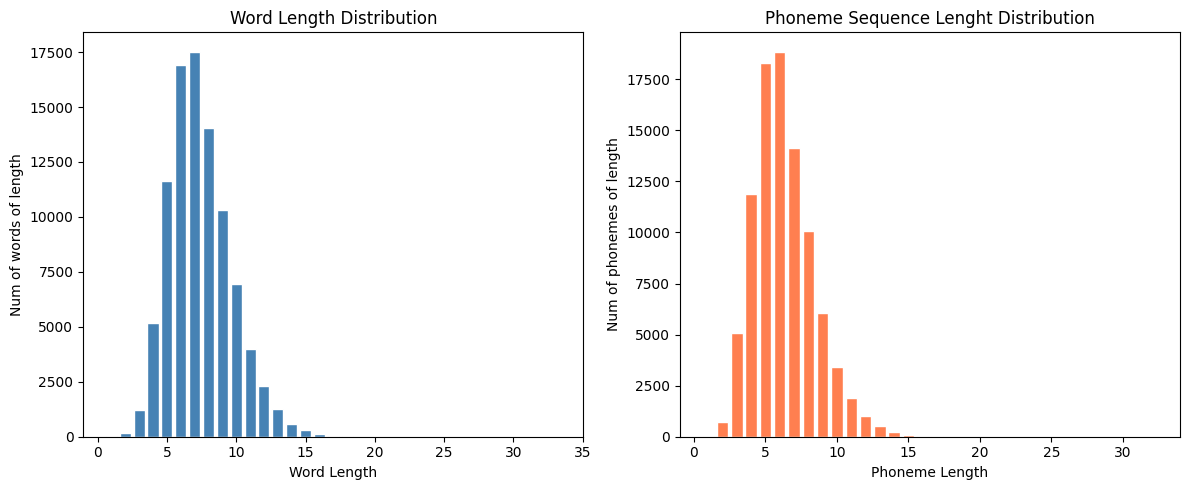

In [50]:
# Get the lenghts for raw inputs
wd_len_counts = Counter(len(word) for word, _ in train_dataset.pairs)
ph_len_counts = Counter(len(ph.split(" ")) for _, ph in train_dataset.pairs)

# Sort by length
wd_len_counts = dict(sorted(wd_len_counts.items()))
ph_len_counts = dict(sorted(ph_len_counts.items()))

# Plot the Words and Phonemes Length Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(wd_len_counts.keys(), wd_len_counts.values(), color="steelblue", edgecolor="white")
axes[0].set_title("Word Length Distribution")
axes[0].set_xlabel("Word Length")
axes[0].set_ylabel("Num of words of length")

axes[1].bar(ph_len_counts.keys(), ph_len_counts.values(), color="coral", edgecolor="white")
axes[1].set_title("Phoneme Sequence Lenght Distribution")
axes[1].set_xlabel("Phoneme Length")
axes[1].set_ylabel("Num of phonemes of length")

plt.tight_layout()
plt.show()

## 2. LSTM cell

In [53]:
# Tutorial 3 Implementation
# @author Francois Meyer

class LSTMCell(nn.Module):
    """
    Single LSTM cell implementing the six gating equations.
    params:
        input_size:  dimensionality of input x_t
        hidden_size: dimensionality of hidden state h_t and cell state c_t
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        
        # Forget gate
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))
    
        # Input gate
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))
       
        # Output gate
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))

        # Cell content
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))
        


    def forward(self, x, h_prev, c_prev):
        """
        Compute one LSTM timestep.
        params:
            x:      input at current timestep, shape (batch, input_size)
            h_prev: previous hidden state,     shape (batch, hidden_size)
            c_prev: previous cell state,       shape (batch, hidden_size)
        returns:
            h: new hidden state, shape (batch, hidden_size)
            c: new cell state,   shape (batch, hidden_size)
        """
        # Apply gate activations
        i_t = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + self.b_f)    # input gate
        f_t = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + self.b_i)    # Forget gate
        o_t = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + self.b_o)       # candidate memory
        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h_prev) + self.b_c)    # Output gate

        # Update cell state
        c_next = f_t * c_prev + i_t * c_tilde

        # Update hiddem state
        h_next = o_t * torch.tanh(c_next)

        return h_next, c_next

## 3. Encoder-decoder Implementation

In [ ]:
class Encoder(nn.Module):
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(
            num_embeddings=src_vocab_size, 
            embedding_dim=embed_dim, 
            padding_idx=0
        )

        self.lstm = LSTMCell(
            input_size=embed_dim,
            hidden_size=hidden_size
        )


    def forward(self, src):
        """
        Parameters:
            src: token indices, shape (batch, src_len)
        Returns:
            all_h: shape (src_len, batch, hidden_size),
            h_n, c_n: shape (num_layers, batch, hidden_size)
        """
        batch_size, seq_len = src.shape
        
        emb = self.embedding(src)    # (batch_size, seq_len, embed_dim)
        
        h = torch.zeros(batch_size, self.hidden_size, device=src.device)

        c = torch.zeros(batch_size, self.hidden_size, device=src.device)

        all_h = []
        for t in range(seq_len):
            x_t = emb[:, t, :]         # x shape: (batch_size, emd_dim) for first layer

            h, c = self.lstm(x_t, h, c)
            
            all_h.append(h)

        all_h = torch.stack(all_h, dim=0)

        h_n = h.unsqueeze(0)
        c_n = c.unsqueeze(0)

        return all_h, (h_n, c_n)